# CatBoost Classifier

In [ ]:
# imports
%pip install pandas scikit-learn catboost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, brier_score_loss
import numpy as np
import matplotlib.pyplot as plt

## 1. Data preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1-1. Data Loading

In [ ]:
# Import `all_dataset.csv`
df = pd.read_csv('/content/drive/MyDrive/Assets/all_dataset.csv')

df.head()

,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
0,0,0,0,0,0,0,0,0,0,0,...,0,0,NaN,NaN,inf,inf,inf,inf,NaN,NaN
1,60017,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.000000,0.041655,0.041655,0.000083,0.000083,NaN,NaN
2,120046,0,0,0,0,0,0,0,0,0,...,0,0,0.000067,0.000092,0.024016,0.027648,0.000050,0.000050,0.000000,inf
3,180116,0,0,0,0,0,0,0,0,0,...,0,0,0.000333,0.000272,0.024978,0.026333,0.000072,0.000072,0.000000,inf
4,240131,0,0,0,0,0,0,0,0,0,...,0,0,0.000362,0.000346,0.026027,0.028230,0.000067,0.000075,0.666667,6.0


### 1-2. Remove Irrelevant Columns

In [ ]:
# Drop `timestamp` column
df.drop('timestamp', axis=1, inplace=True)

### 1-3. Handle Missing Values

In [ ]:
# Replace missing values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Replace NaN with 0
df.fillna(0, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
BLUE.HEXTECH_DRAGON.kills,0
BLUE.WATER_DRAGON.kills,0
BLUE.FIRE_DRAGON.kills,0
BLUE.EARTH_DRAGON.kills,0
BLUE.AIR_DRAGON.kills,0
BLUE.CHEMTECH_DRAGON.kills,0
BLUE.ELDER_DRAGON.kills,0
BLUE.RIFTHERALD.kills,0
BLUE.BARON_NASHOR.kills,0
BLUE.HORDE.kills,0


### 1-4. Define Target and Features

In [ ]:
X = df.drop('winner', axis=1)
y = df['winner']

### 1-5. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5269809, 40) (1317453, 40) (5269809,) (1317453,)


## 2. CatBoost Algorithm

In [ ]:
# Initialize the CatBoost model
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=False
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=10
)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7327


## 3. Fine Tuning

In [ ]:
# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'iterations': randint(100, 500),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(4, 10),
    'l2_leaf_reg': randint(1, 10),
    'bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS'],
    'random_seed': [42]
}

# Initialize the base model
base_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=False
)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,       # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=10,
    random_state=42
)

# Perform random search
random_search.fit(X_train, y_train)

# Print best parameters
print("\nBest parameters found:")
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters found:
{'bootstrap_type': 'Bernoulli', 'depth': 9, 'iterations': 430, 'l2_leaf_reg': 7, 'learning_rate': 0.278827389977048, 'random_seed': 42}


In [ ]:
# Print best score
print(f"\nBest cross-validation accuracy: {random_search.best_score_:.4f}")

# Get the best model
best_model = random_search.best_estimator_


Best cross-validation accuracy: 0.7442


## 4. Model Evaluation

In [ ]:
# Evaluate the best model on test set
y_pred = best_model.predict(X_test)

### 4-1. Global Metrics

********** MODEL SCORES **********
Mean Absolute Error (MAE): 0.2673
Mean Squared Error (MSE): 0.2673
Root Mean Squared Error (RMSE): 0.5170
R^2 Score: -0.0696
f1 Score: 0.7130
Precision Score: 0.7529
Recall Score: 0.6772
Brier Score: 0.2673
Accuracy: 0.7327
**********************************


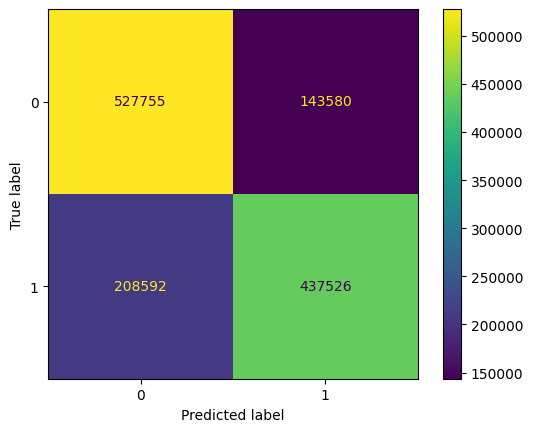

In [ ]:
# Evaluate the model
def model_evaluation(y_test, y_pred):
    """
    Evaluate the model using :
    - Mean Absolute Error
    - Mean Squared Error
    - Root Mean Squared Error
    - R^2 Score
    - F1 Score
    - Precision Score
    - Recall Score
    """
    # Evaluate the model using MAE, MSE, RMSE, R^2 Score, F1 score, Precision Score and Recall Score
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    brier_score = brier_score_loss(y_test, y_pred)

    # Legacy mode (convert probabilities to binary; threshold set to '> 0.5')
    y_pred_binary = (y_pred > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred_binary)
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    accuracy = accuracy_score(y_test, y_pred_binary)

    # Print the scores
    print("********** MODEL SCORES **********")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"f1 Score: {f1:.4f}")
    print(f"Precision Score: {precision:.4f}")
    print(f"Recall Score: {recall:.4f}")
    print(f"Brier Score: {brier_score:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print("**********************************")

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()


model_evaluation(y_test, y_pred)

### 4-2. ROC Curve and AUC-ROc Score

ROC AUC: 0.7316443894706907


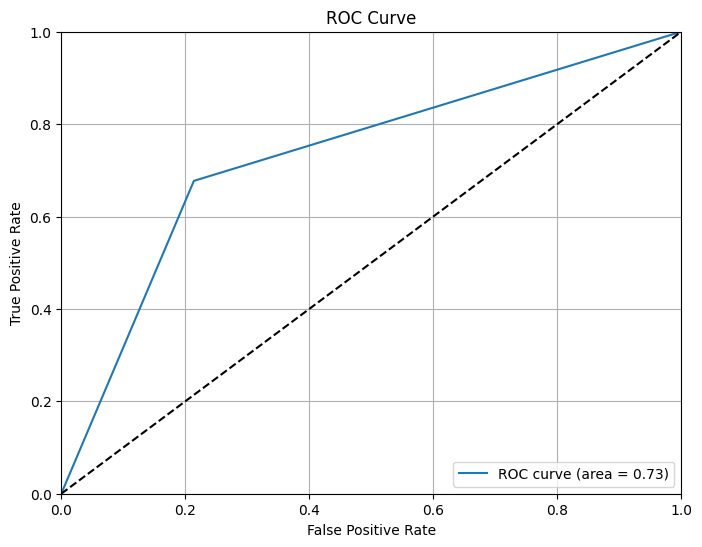

In [ ]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate the ROC AUC
roc_auc = roc_auc_score(y_test, y_pred)
print('ROC AUC:', roc_auc)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.grid()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()